In [8]:
import os
import pandas as pd
import numpy as np

# Define paths (Adjust if your files are in a different subdirectory)
DATA_DIR = "/content/drive/MyDrive/"

print("🚀 Step 1: Loading Datasets...")
customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"))
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"))
support_tickets = pd.read_csv(os.path.join(DATA_DIR, "support_tickets.csv"))
web_events = pd.read_csv(os.path.join(DATA_DIR, "web_events_snapshot.csv"))
churn_labels = pd.read_csv(os.path.join(DATA_DIR, "churn_labels.csv"))
intervention = pd.read_csv(os.path.join(DATA_DIR, "intervention_history.csv"))
rfm_snapshot = pd.read_csv(os.path.join(DATA_DIR, "rfm_modeling_snapshot.csv"))

SNAPSHOT_DATE = pd.to_datetime("2025-09-30")

# ==========================================
# 🛠️ STEP 2: DATA CLEANING & AUDIT (Part 1 Requirements)
# ==========================================
print("\n🧹 Step 2: Resolving Intentional Data Quality Issues...")

# 1. Handle Duplicate-like records in orders (_DUP)
initial_order_count = len(orders)
orders = orders[~orders['order_id'].str.endswith('_DUP', na=False)]
print(f"   - Removed {initial_order_count - len(orders)} duplicate-like records ending with '_DUP'.")

# Convert dates to datetime objects
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
support_tickets['ticket_date'] = pd.to_datetime(support_tickets['ticket_date'])

# 2. Enforce Leakage Rule (Filter out post-snapshot orders for feature building)
pre_snapshot_orders = orders[orders['order_date'] <= SNAPSHOT_DATE].copy()
print(f"   - Filtered out {len(orders) - len(pre_snapshot_orders)} post-snapshot orders to prevent data leakage.")

# 3. Handle Missing values in customers
customers['loyalty_tier'] = customers['loyalty_tier'].fillna('None')
customers['skin_type'] = customers['skin_type'].fillna('Unknown')
print("   - Filled missing 'loyalty_tier' with 'None' and 'skin_type' with 'Unknown'.")

# 4. Handle Missing ratings in orders
# Replace missing ratings with the customer's average or global average if unavailable
global_avg_rating = pre_snapshot_orders['rating'].mean()
pre_snapshot_orders['rating'] = pre_snapshot_orders['rating'].fillna(global_avg_rating)
print(f"   - Filled missing order ratings with global pre-snapshot average ({global_avg_rating:.2f}).")

# 5. Treat Outlier order values (Capping gross_amount at 99th percentile)
cap_value = pre_snapshot_orders['gross_amount'].quantile(0.99)
pre_snapshot_orders['gross_amount'] = np.where(pre_snapshot_orders['gross_amount'] > cap_value, cap_value, pre_snapshot_orders['gross_amount'])
print(f"   - Capped gross_amount outliers at 99th percentile (₹{cap_value:.2f}).")


# ==========================================
# 📊 STEP 3: BASELINE BUSINESS METRICS
# ==========================================
print("\n📈 Step 3: Calculating Core Business Metrics...")

# Calculate total revenue & average order value (AOV) pre-snapshot
total_revenue = pre_snapshot_orders['gross_amount'].sum()
aov = pre_snapshot_orders['gross_amount'].mean()
print(f"   - Pre-snapshot Total Revenue: ₹{total_revenue:,.2f}")
print(f"   - Pre-snapshot Average Order Value (AOV): ₹{aov:.2f}")

# Overall Churn Rate base check
overall_churn = churn_labels['churn_next_60d'].mean()
print(f"   - Base Dataset Churn Rate (Next 60 Days): {overall_churn * 100:.2f}%")


# ==========================================
# 🔗 STEP 4: CREATE THE CLEAN MASTER AUDIT TABLE
# ==========================================
print("\n🔗 Step 4: Merging Datasets using Left Joins...")

# Combine customer profiles with their respective target split and labels
master_df = customers.merge(churn_labels[['customer_id', 'churn_next_60d', 'split']], on='customer_id', how='left')

# Merge the pre-aggregated web events snapshot
master_df = master_df.merge(web_events.drop(columns=['snapshot_date']), on='customer_id', how='left')

# Merge intervention data
master_df = master_df.merge(intervention.drop(columns=['snapshot_date']), on='customer_id', how='left')

print(f"   - Master audit dataframe compiled successfully. Shape: {master_df.shape}")

# Save the audited, baseline dataset
master_df.to_csv("cleaned_master_audit.csv", index=False)
print("💾 Saved 'cleaned_master_audit.csv' to your workspace.")
print("\n🎉 Part 1 Data Infrastructure Complete!")

🚀 Step 1: Loading Datasets...

🧹 Step 2: Resolving Intentional Data Quality Issues...
   - Removed 12 duplicate-like records ending with '_DUP'.
   - Filtered out 1869 post-snapshot orders to prevent data leakage.
   - Filled missing 'loyalty_tier' with 'None' and 'skin_type' with 'Unknown'.
   - Filled missing order ratings with global pre-snapshot average (3.87).
   - Capped gross_amount outliers at 99th percentile (₹2343.24).

📈 Step 3: Calculating Core Business Metrics...
   - Pre-snapshot Total Revenue: ₹6,013,675.39
   - Pre-snapshot Average Order Value (AOV): ₹739.87
   - Base Dataset Churn Rate (Next 60 Days): 46.96%

🔗 Step 4: Merging Datasets using Left Joins...
   - Master audit dataframe compiled successfully. Shape: (2400, 22)
💾 Saved 'cleaned_master_audit.csv' to your workspace.

🎉 Part 1 Data Infrastructure Complete!


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Create directory to save outputs
OUTPUT_DIR = "eda_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define data directory
DATA_DIR = "/content/drive/MyDrive/"

print("🚀 Loading data files...")
customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"))
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"))
support_tickets = pd.read_csv(os.path.join(DATA_DIR, "support_tickets.csv"))
web_events = pd.read_csv(os.path.join(DATA_DIR, "web_events_snapshot.csv"))
churn_labels = pd.read_csv(os.path.join(DATA_DIR, "churn_labels.csv"))

SNAPSHOT_DATE = pd.to_datetime("2025-09-30")
orders['order_date'] = pd.to_datetime(orders['order_date'])

# -------------------------------------------------------------
# 🛠️ DATA CLEANING & AUDIT (From Data Dictionary Specifications)
# -------------------------------------------------------------
# Remove duplicate-like records ending with '_DUP'
orders_clean = orders[~orders['order_id'].str.endswith('_DUP', na=False)].copy()

# Enforce LEAKAGE RULE: Use only data on or before 2025-09-30
pre_snapshot_orders = orders_clean[orders_clean['order_date'] <= SNAPSHOT_DATE].copy()

# Compile Master Profile DataFrame for Analysis
master_df = customers.merge(churn_labels[['customer_id', 'churn_next_60d', 'split']], on='customer_id', how='left')
master_df = master_df.merge(web_events.drop(columns=['snapshot_date']), on='customer_id', how='left')

# Fill missing customer variables for clean grouping
master_df['loyalty_tier'] = master_df['loyalty_tier'].fillna('Not Enrolled')
master_df['skin_type'] = master_df['skin_type'].fillna('Not Provided')


# -------------------------------------------------------------
# 📊 CHART 1: Outlier Identification & Gross Amount Distribution
# -------------------------------------------------------------
print("📊 Generating Chart 1: Order Value Outliers...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before capping distribution boxplot
sns.boxplot(x=pre_snapshot_orders['gross_amount'], ax=ax1, color='#e74c3c')
ax1.set_title("Detection of Outliers in Gross Order Amount")
ax1.set_xlabel("Gross Amount (₹)")

# Apply 99th percentile cap to handle outliers responsibly
cap_val = pre_snapshot_orders['gross_amount'].quantile(0.99)
capped_orders = pre_snapshot_orders['gross_amount'].clip(upper=cap_val)

sns.histplot(capped_orders, bins=30, kde=True, ax=ax2, color='#2ecc71')
ax2.set_title(f"Distribution After Capping at 99th Pctl (₹{cap_val:.2f})")
ax2.set_xlabel("Gross Amount (₹)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart1_gross_amount_outliers.png", dpi=300)
plt.close()


# -------------------------------------------------------------
# 📊 CHART 2: Churn Rate by Acquisition Channel
# -------------------------------------------------------------
print("📊 Generating Chart 2: Churn by Acquisition Channel...")
plt.figsize=(10, 6)
channel_churn = master_df.groupby('acquisition_channel')['churn_next_60d'].mean().reset_index()
channel_churn = channel_churn.sort_values(by='churn_next_60d', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='churn_next_60d', y='acquisition_channel', data=channel_churn, palette='coolwarm')
plt.axvline(x=master_df['churn_next_60d'].mean(), color='red', linestyle='--', label=f"Avg Churn ({master_df['churn_next_60d'].mean()*100:.1f}%)")
plt.title("Customer Churn Probability Across Acquisition Channels")
plt.xlabel("Churn Rate (Next 60 Days)")
plt.ylabel("Acquisition Channel")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart2_churn_by_channel.png", dpi=300)
plt.close()


# -------------------------------------------------------------
# 📊 CHART 3: App Engagement Dynamics vs. Churn Risk
# -------------------------------------------------------------
print("📊 Generating Chart 3: Sessions Engagement vs. Churn...")
plt.figure(figsize=(10, 5))
# Create engagement bins
master_df['session_bin'] = pd.qcut(master_df['sessions_30d'].rank(method='first'), q=5, labels=['0-20%', '21-40%', '41-60%', '61-80%', '81-100%'])
bin_churn = master_df.groupby('session_bin', observed=False)['churn_next_60d'].mean().reset_index()

sns.lineplot(x='session_bin', y='churn_next_60d', data=bin_churn, marker='o', linewidth=2.5, color='#1abc9c')
plt.title("The Churn Curve: App/Web Sessions Quintiles vs Churn Probability")
plt.xlabel("30-Day App/Web Session Volume (Quintiles)")
plt.ylabel("Observed Churn Rate")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart3_engagement_vs_churn.png", dpi=300)
plt.close()


# -------------------------------------------------------------
# 📊 CHART 4: Support Ticket Sentiment and Breakdown
# -------------------------------------------------------------
print("📊 Generating Chart 4: Support Ticket Analysis...")
ticket_master = support_tickets.merge(churn_labels, on='customer_id', how='inner')

plt.figure(figsize=(10, 6))
issue_order = ticket_master.groupby('issue_type')['sentiment_score'].mean().sort_values().index
sns.barplot(x='sentiment_score', y='issue_type', hue='churn_next_60d', data=ticket_master, order=issue_order, palette='Set2')
plt.title("Customer Support Sentiment by Issue Type and Churn Fate")
plt.xlabel("Average Sentiment Score (-1 to +1)")
plt.ylabel("Issue Categorization")
plt.legend(title="Churned (1=Yes)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart4_support_tickets_sentiment.png", dpi=300)
plt.close()


# -------------------------------------------------------------
# 📊 CHART 5: Loyalty Program Strategic Impact
# -------------------------------------------------------------
print("📊 Generating Chart 5: Loyalty Status Churn Ratio...")
plt.figure(figsize=(9, 5))
sns.countplot(x='loyalty_tier', hue='churn_next_60d', data=master_df, palette='viridis')
plt.title("Loyalty Tier Distribution Split by Churn Outcome")
plt.xlabel("Loyalty Level Status")
plt.ylabel("Total Count of Customers")
plt.legend(title="Churn Fate", labels=["Retained", "Churned"])
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart5_loyalty_tier_impact.png", dpi=300)
plt.close()


# -------------------------------------------------------------
# 📊 CHART 6: Missing Value Audit Trail Map
# -------------------------------------------------------------
print("📊 Generating Chart 6: Missing Data Audit Trail...")
# Create a dummy combined tracking matrix to visualize structured missing values
audit_nulls = pd.DataFrame({
    'Customer: Skin Type': customers['skin_type'].isna(),
    'Customer: Loyalty Tier': customers['loyalty_tier'].isna(),
    'Orders: Ratings': orders['rating'].isna()
})

# Convert boolean DataFrame to numeric (float) to handle True/False and NaN values for heatmap
audit_nulls = audit_nulls.astype(float)

plt.figure(figsize=(10, 5))
sns.heatmap(audit_nulls, cbar=False, yticklabels=False, cmap='binary')
plt.title("Data Audit Heatmap: Visualizing Missing Values (Black Blocks = Missing)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart6_missing_data_audit.png", dpi=300)
plt.close()

print(f"🎉 Success! 6 meaningful charts generated and exported to standard file formats inside './{OUTPUT_DIR}/'")

🚀 Loading data files...
📊 Generating Chart 1: Order Value Outliers...
📊 Generating Chart 2: Churn by Acquisition Channel...


/tmp/ipykernel_1316/1497492167.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='churn_next_60d', y='acquisition_channel', data=channel_churn, palette='coolwarm')


📊 Generating Chart 3: Sessions Engagement vs. Churn...
📊 Generating Chart 4: Support Ticket Analysis...
📊 Generating Chart 5: Loyalty Status Churn Ratio...
📊 Generating Chart 6: Missing Data Audit Trail...
🎉 Success! 6 meaningful charts generated and exported to standard file formats inside './eda_plots/'


Displaying eda_plots/chart1_gross_amount_outliers.png:


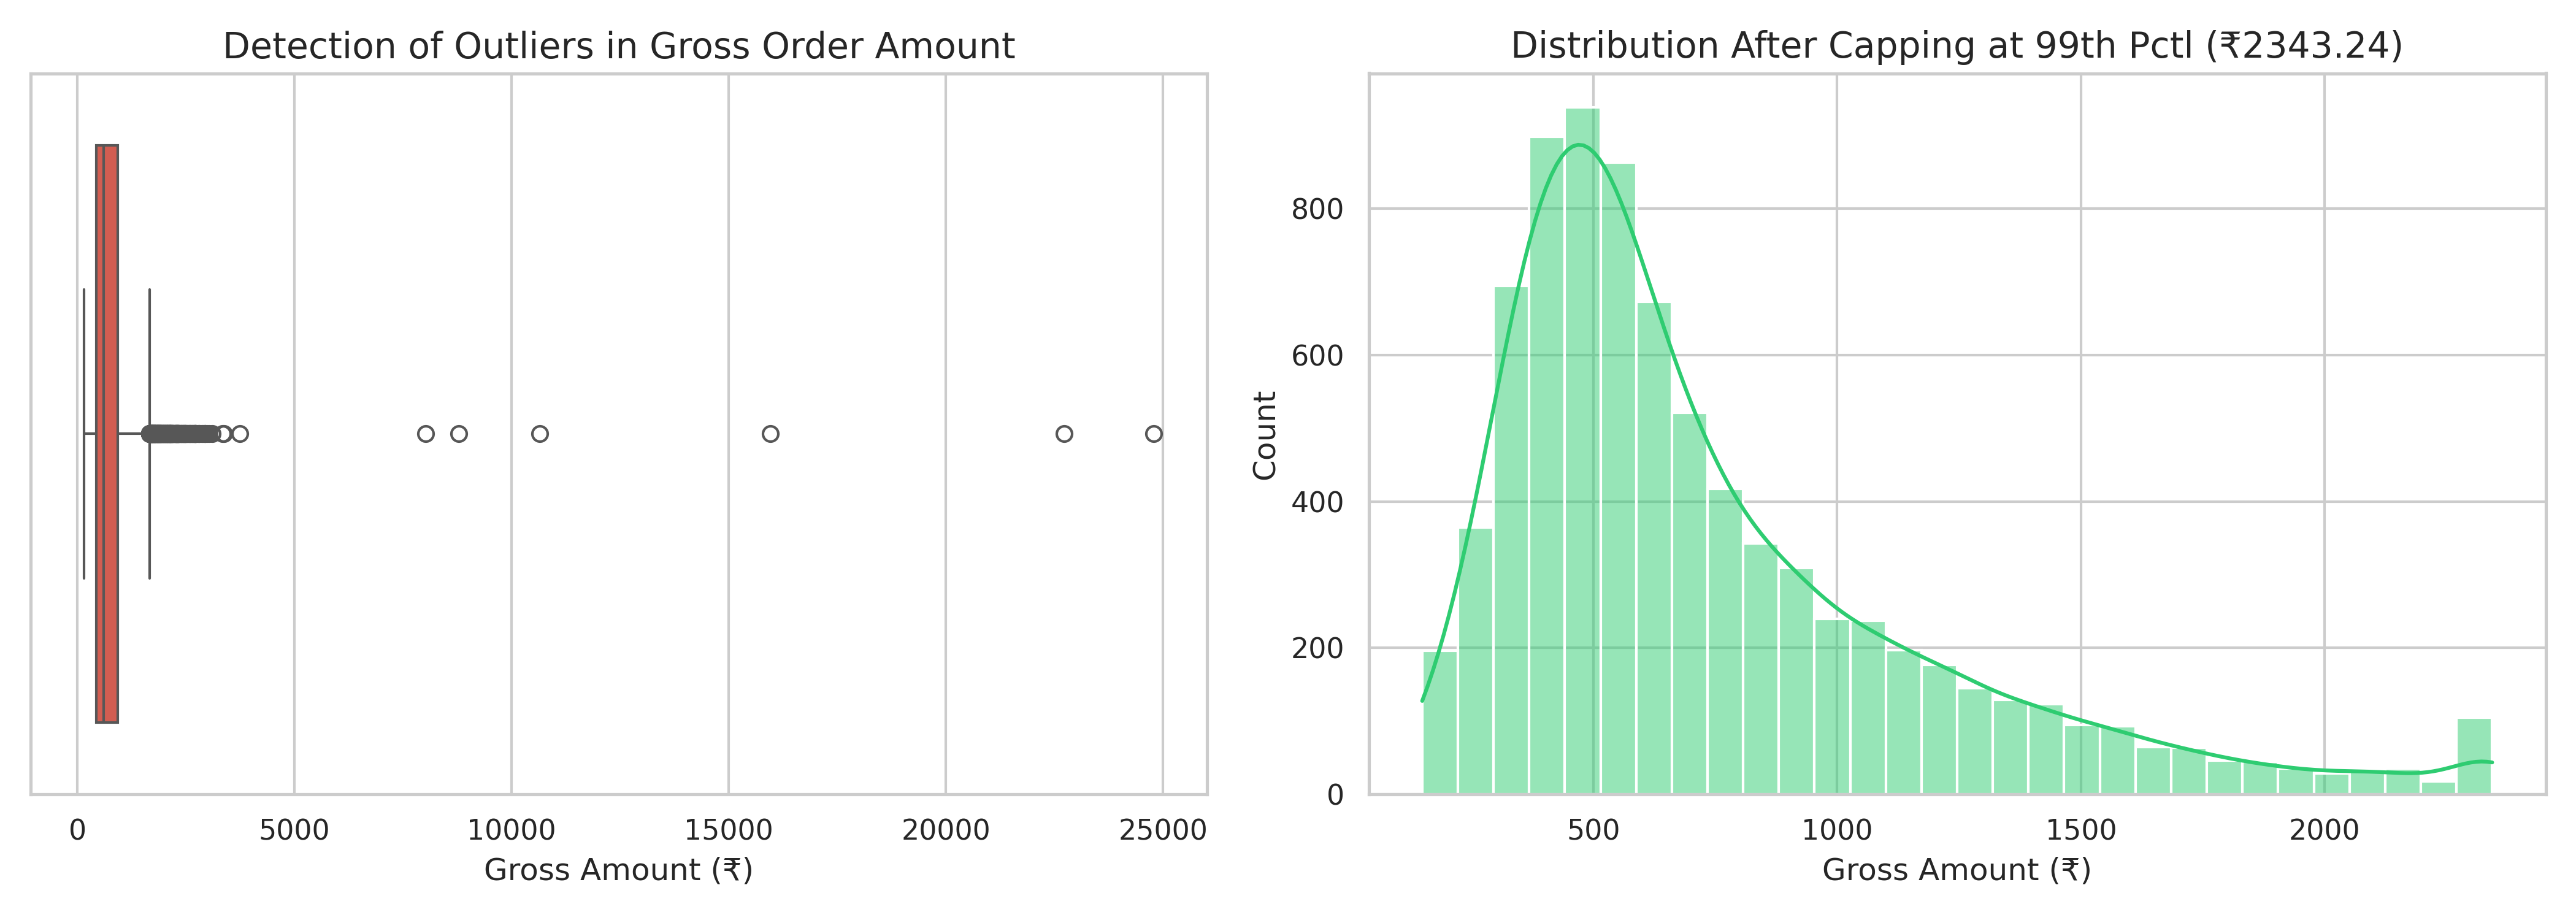

Displaying eda_plots/chart2_churn_by_channel.png:


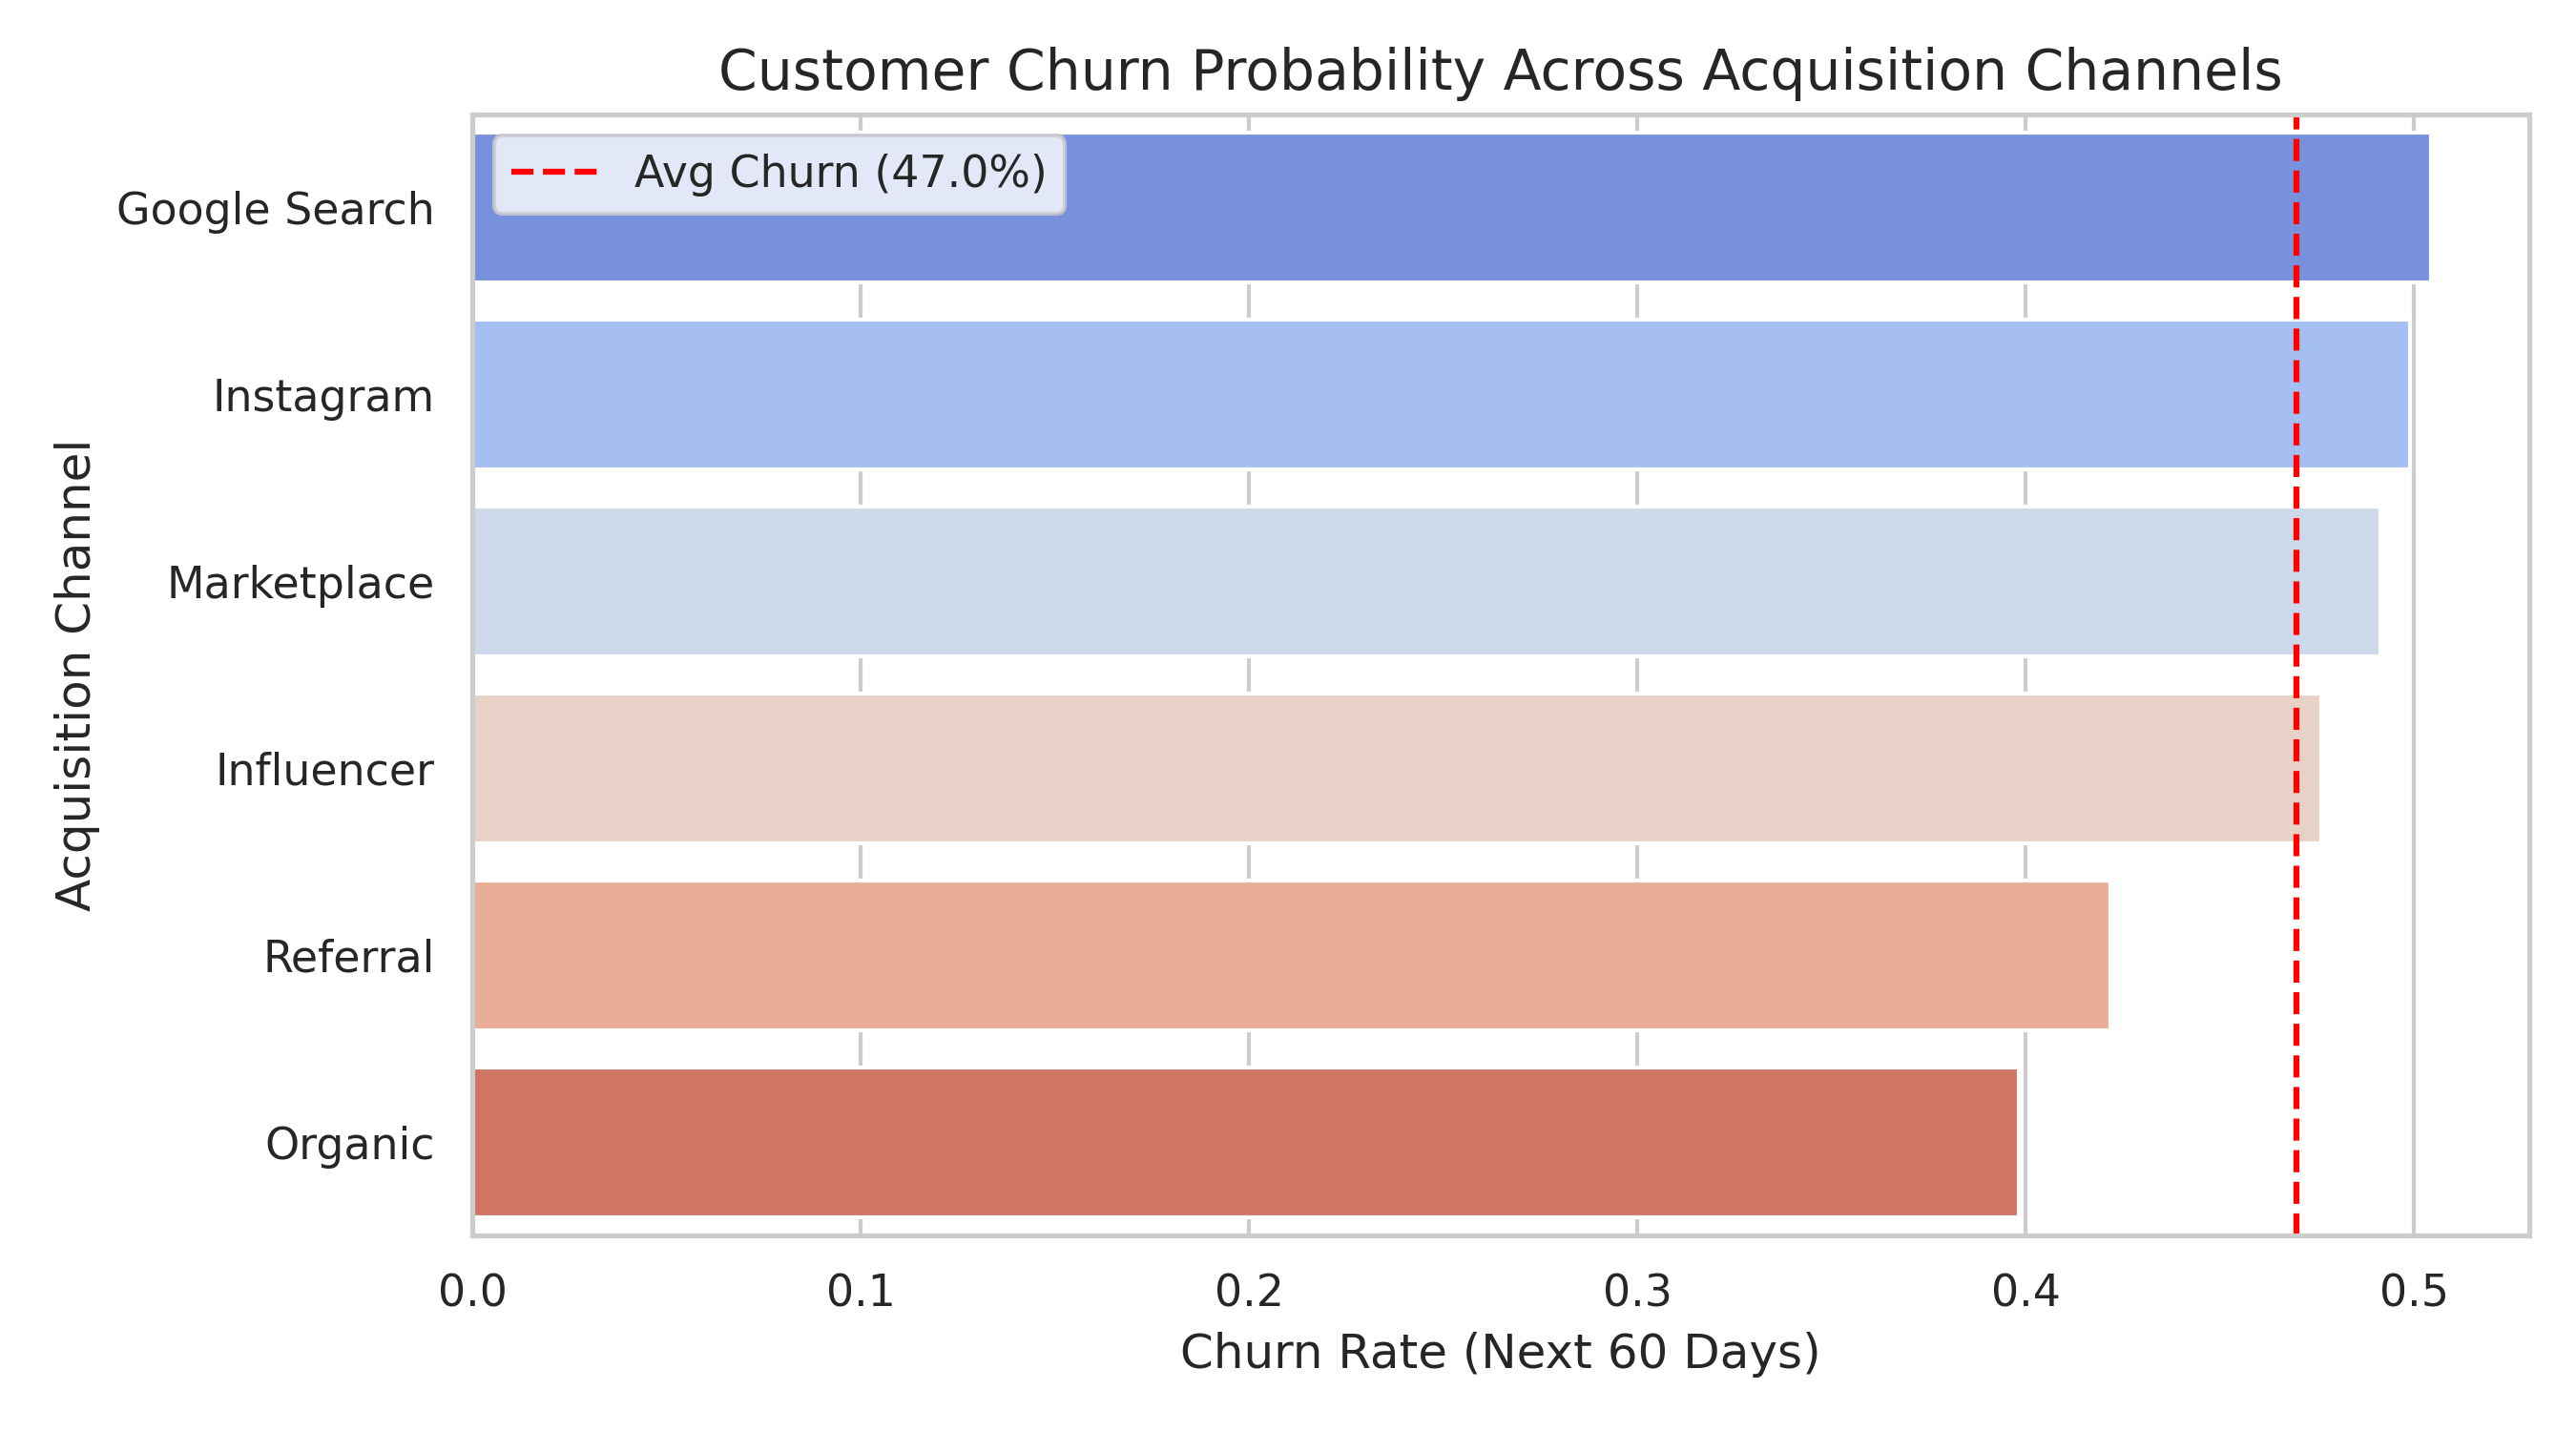

Displaying eda_plots/chart3_engagement_vs_churn.png:


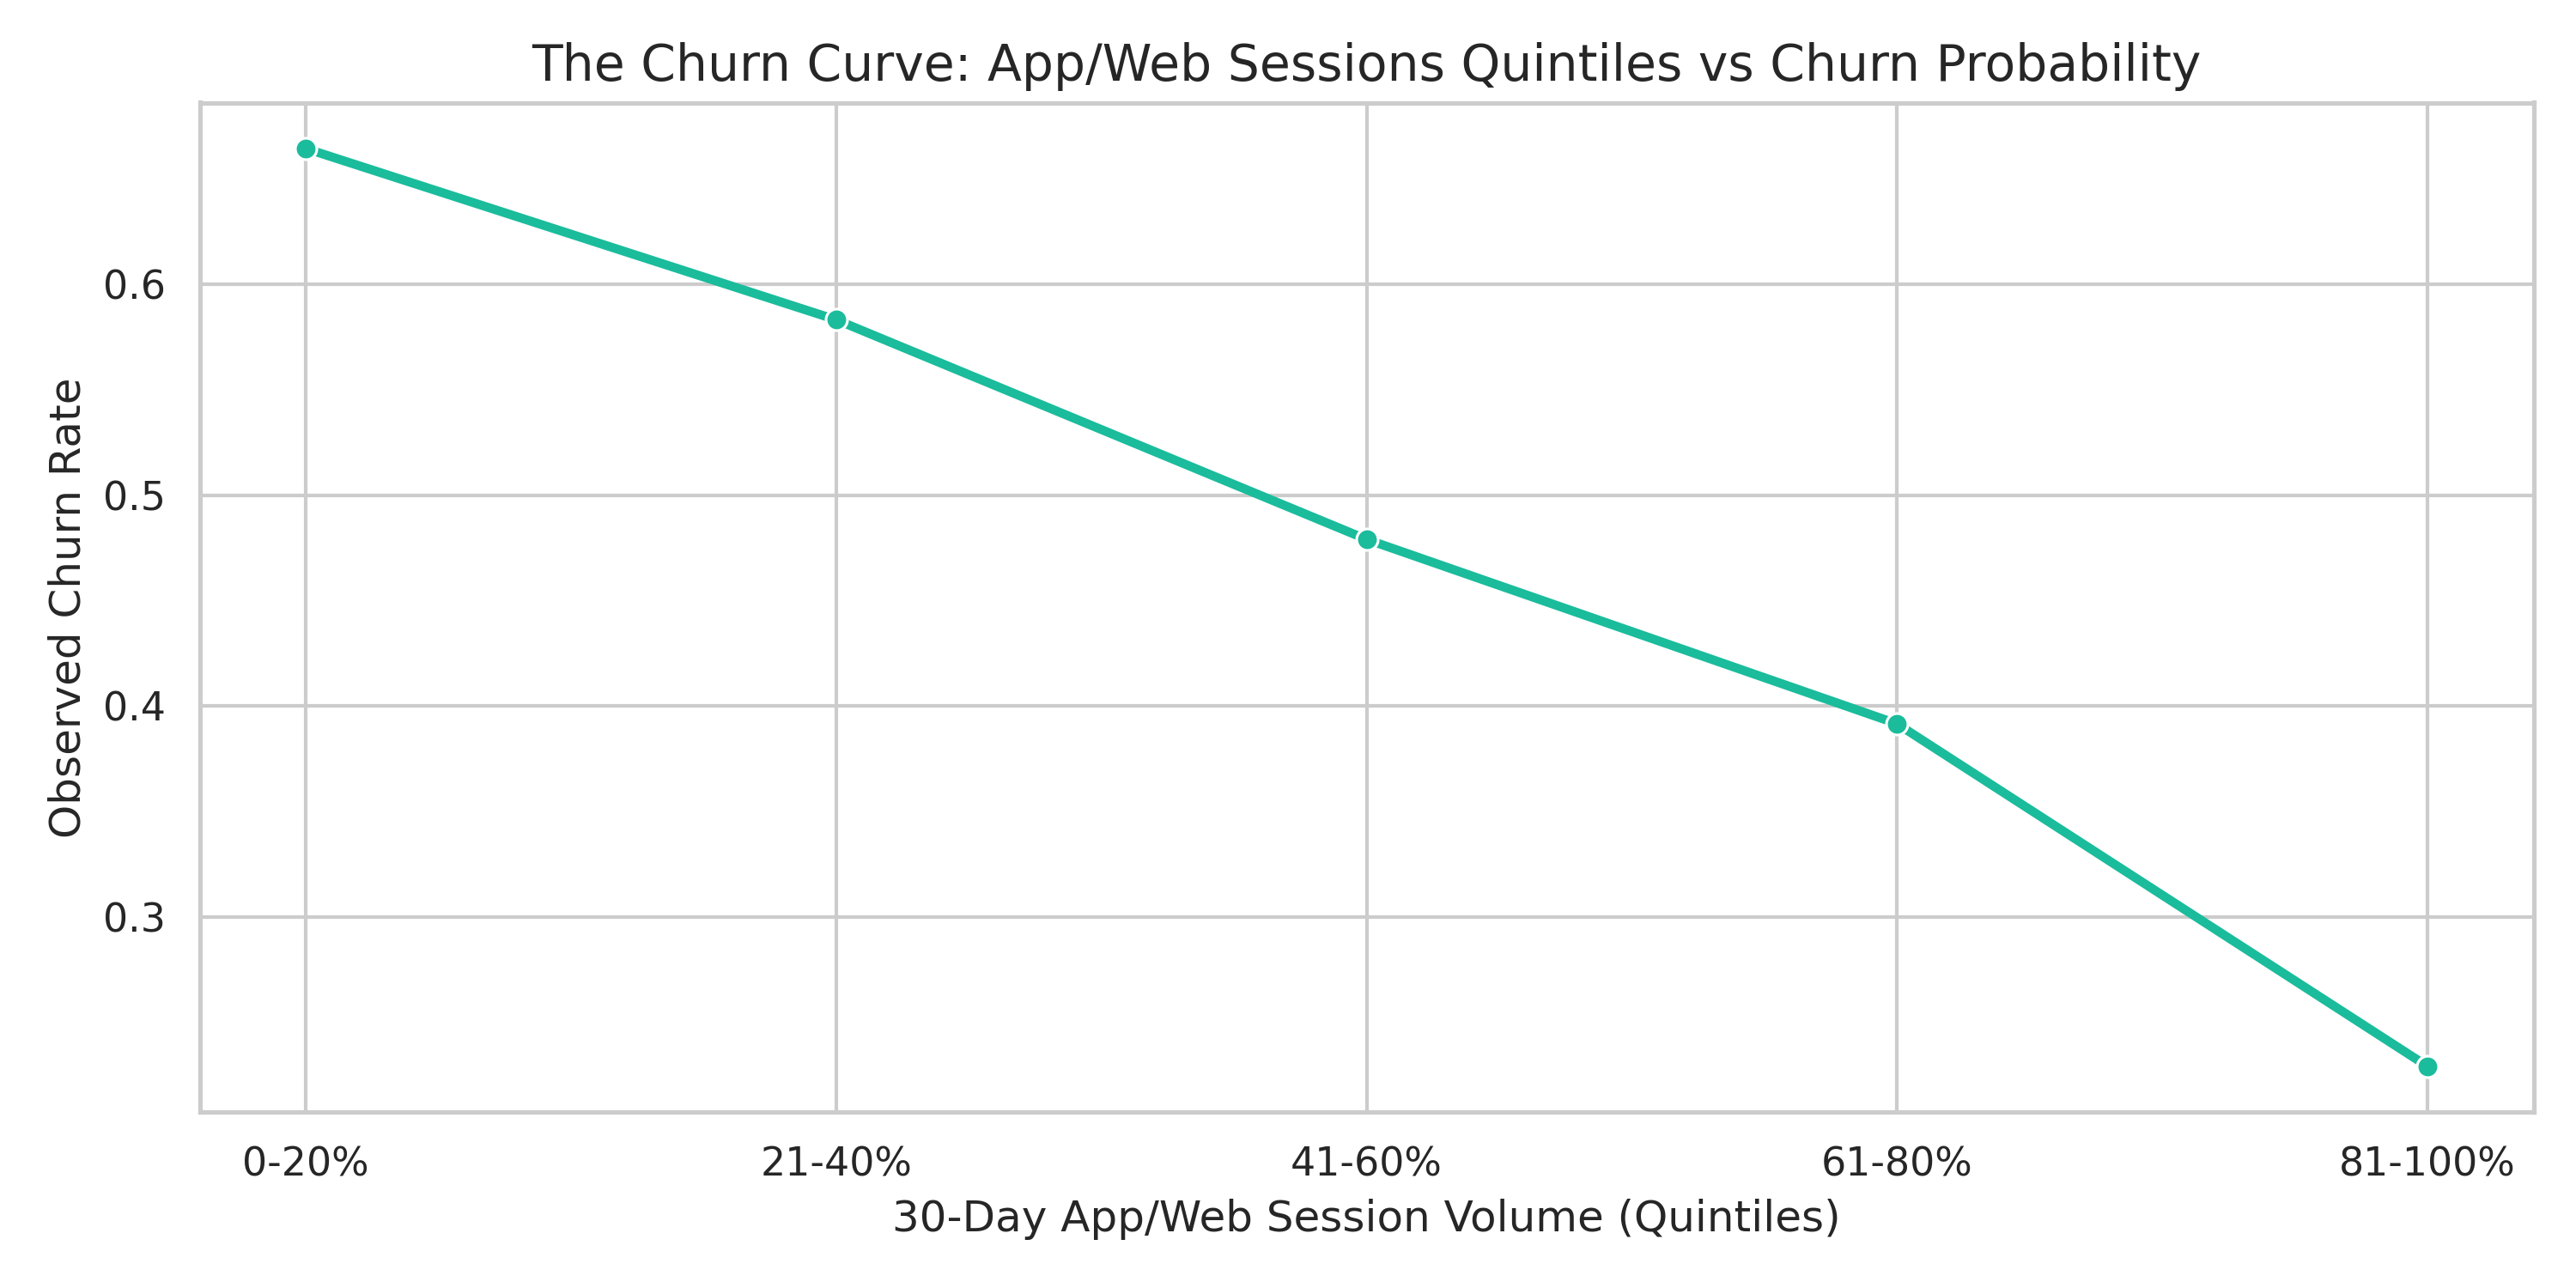

Displaying eda_plots/chart4_support_tickets_sentiment.png:


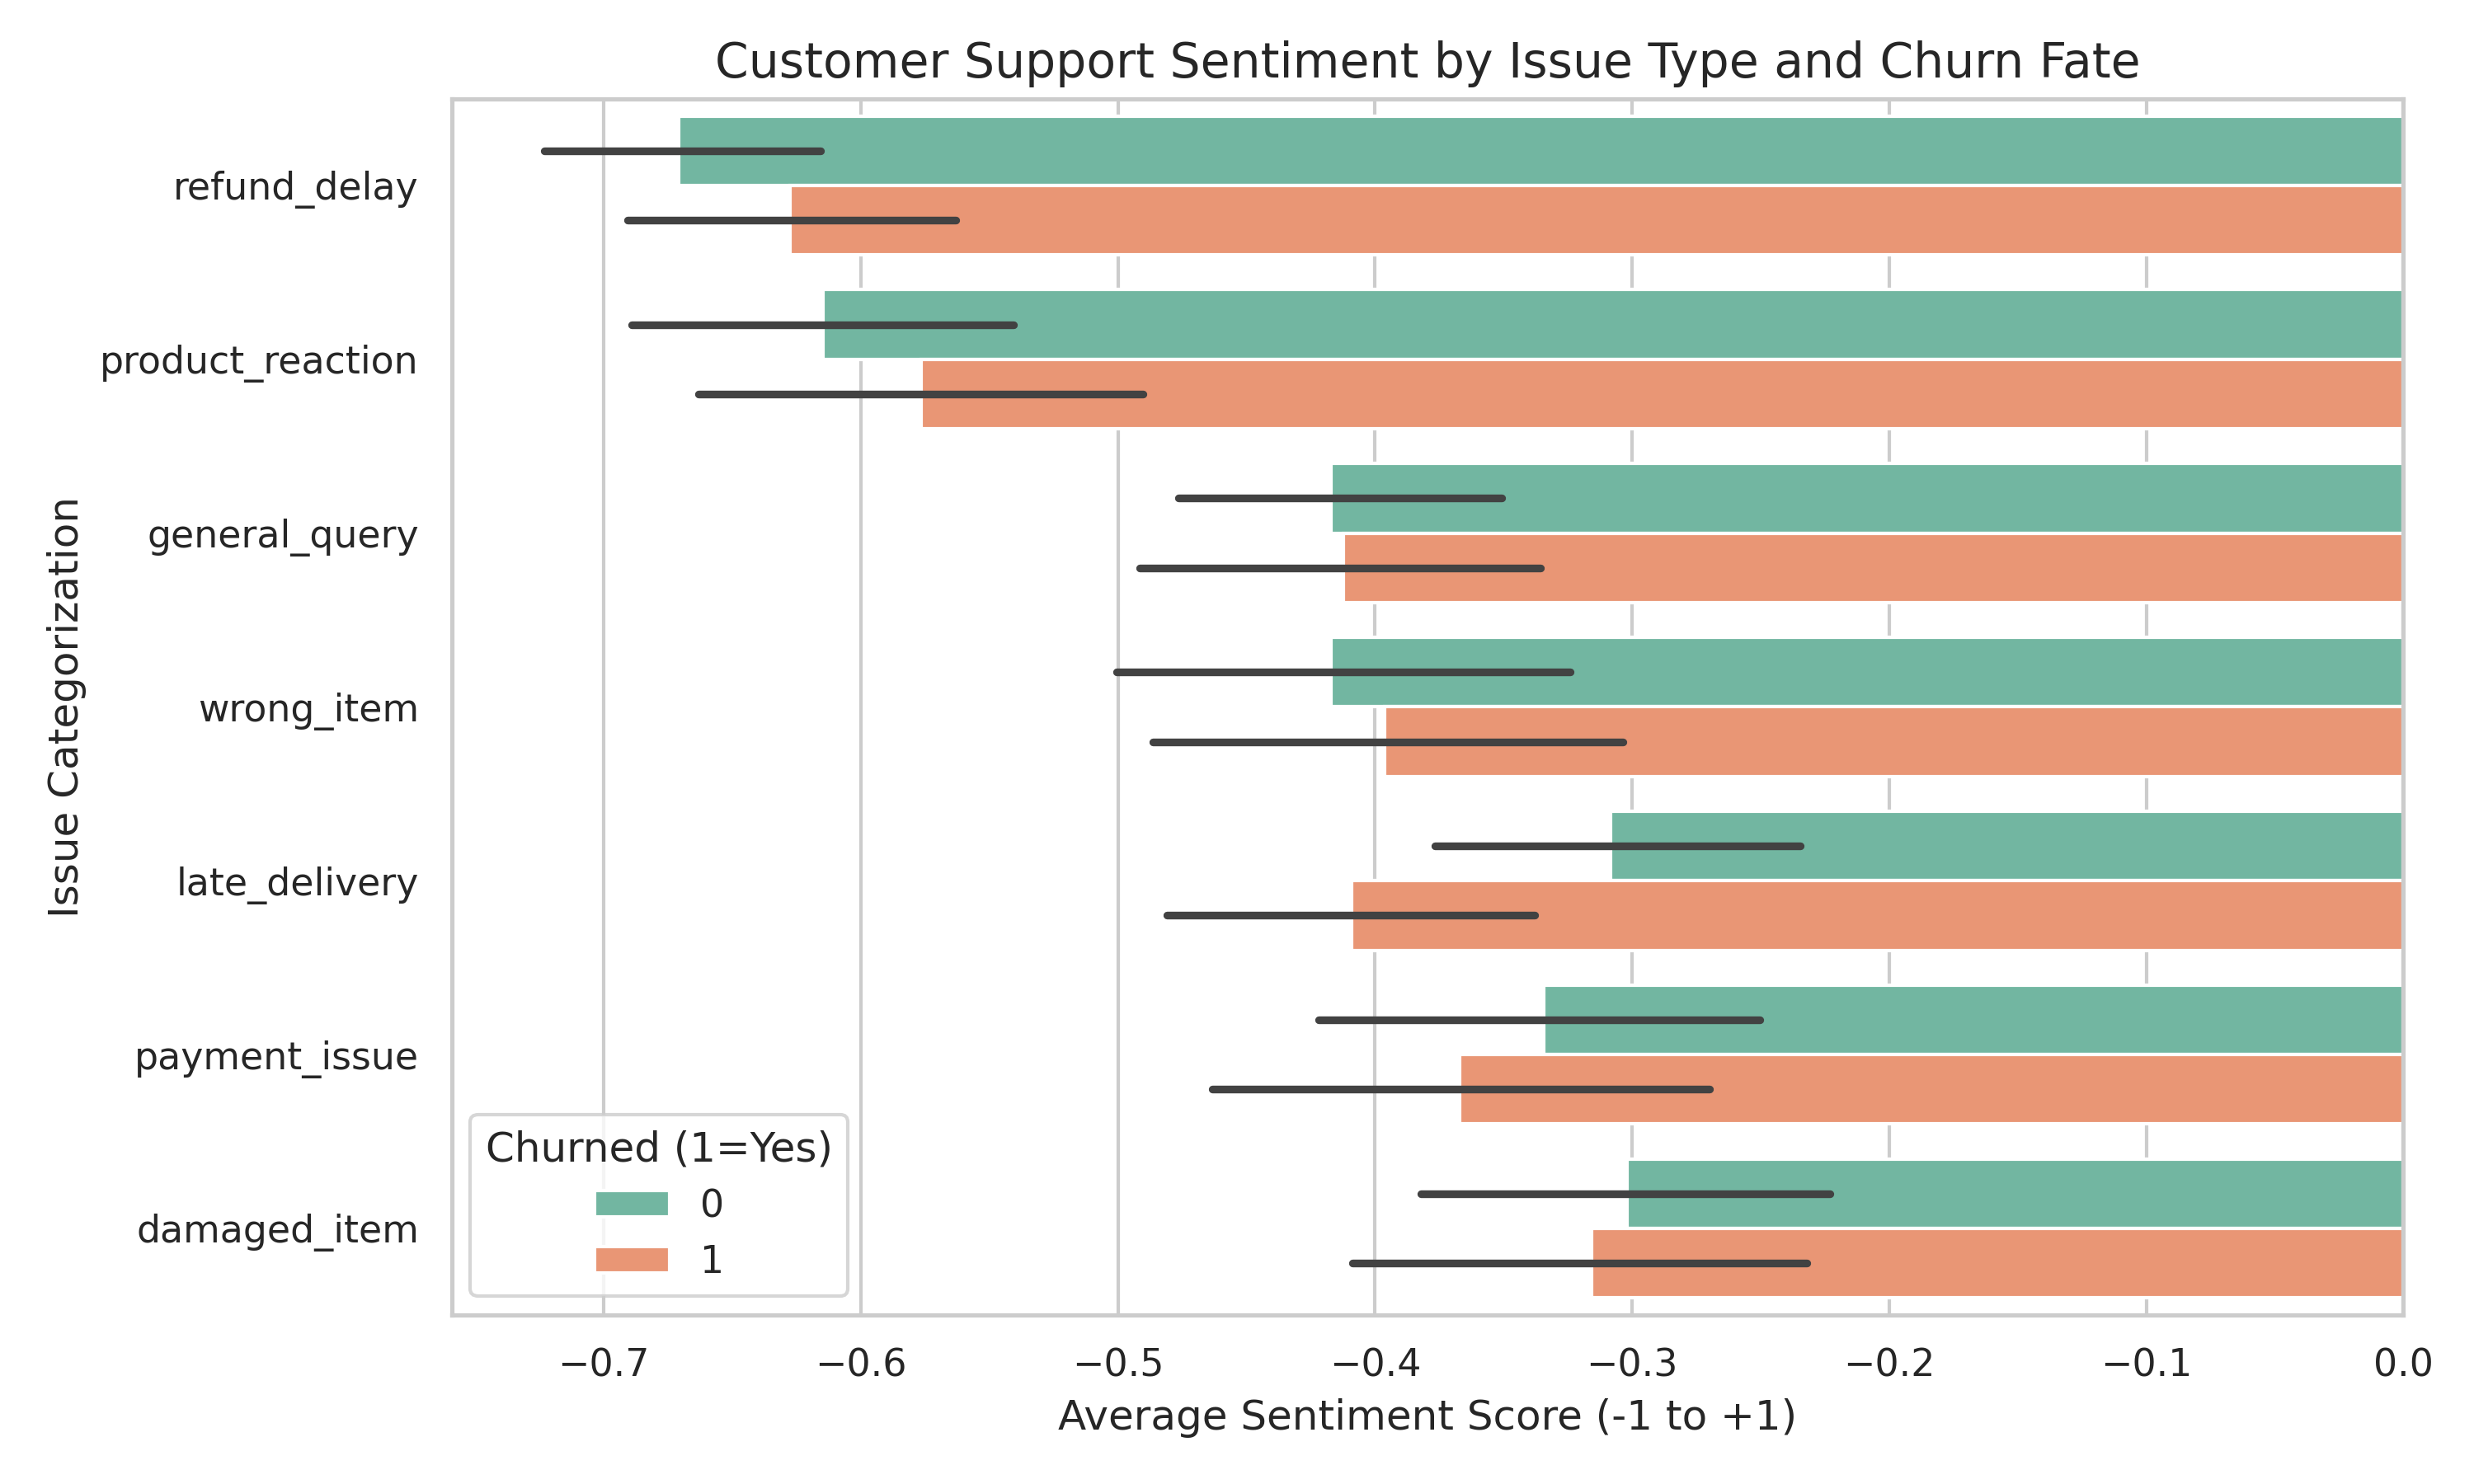

Displaying eda_plots/chart5_loyalty_tier_impact.png:


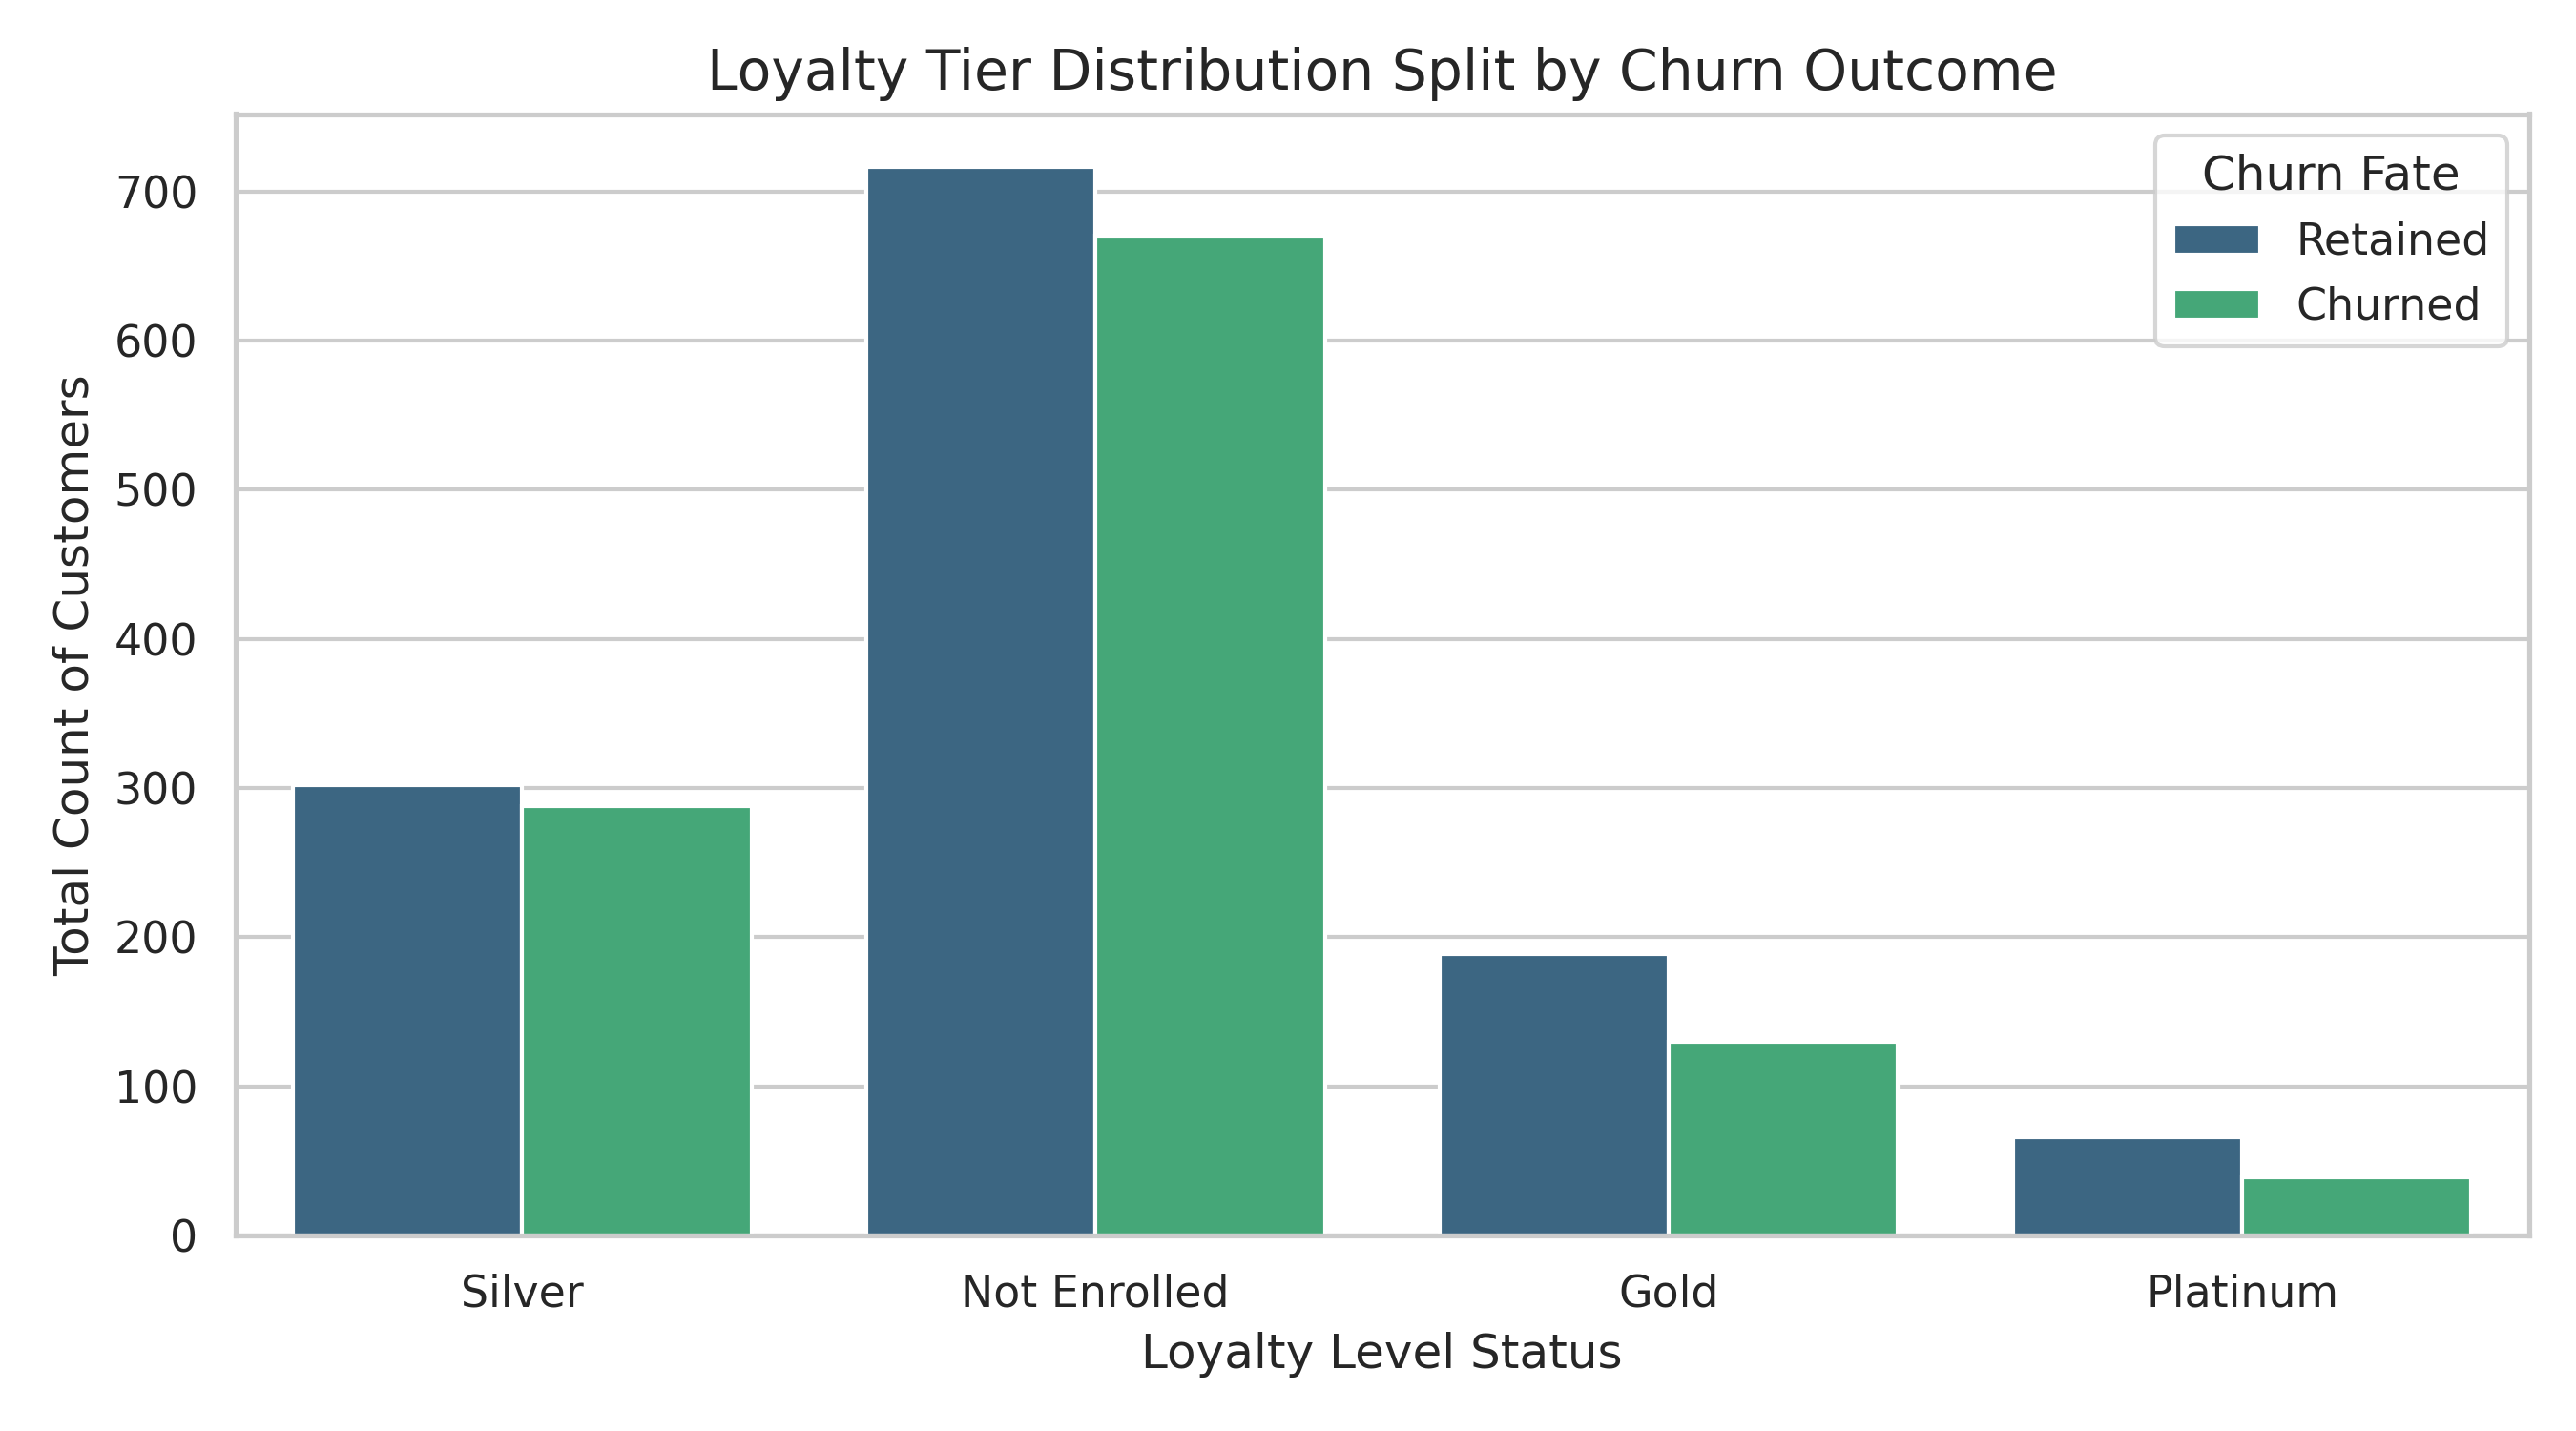

Displaying eda_plots/chart6_missing_data_audit.png:


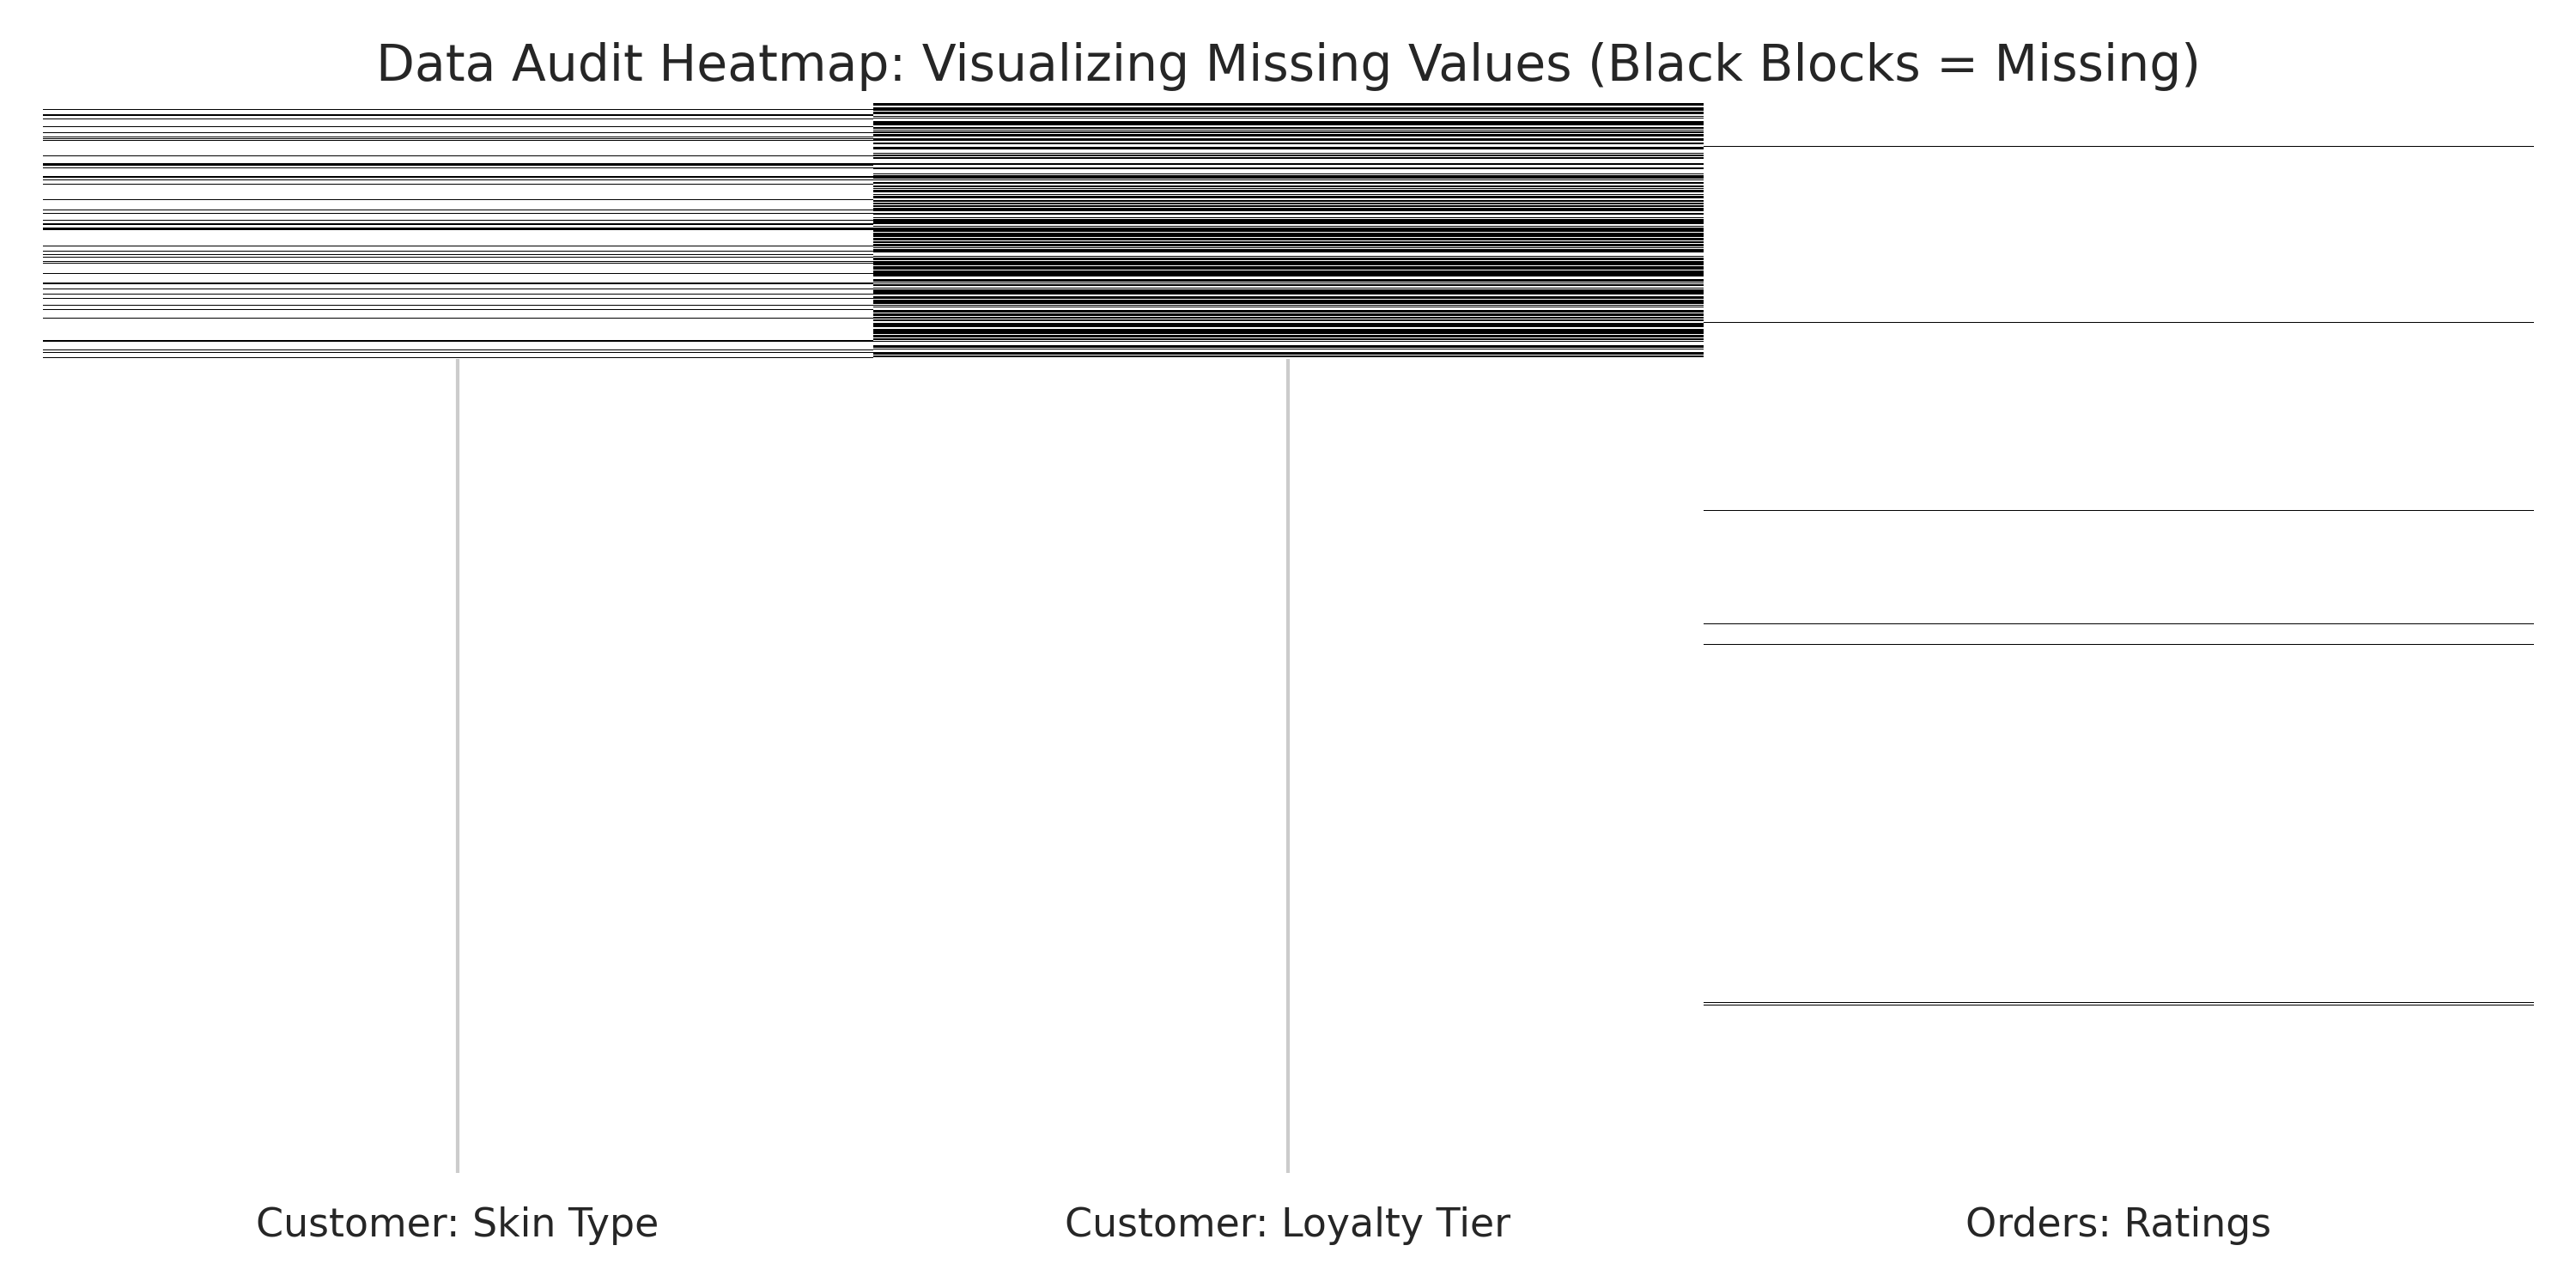

In [9]:
from IPython.display import Image, display

image_files = [
    'eda_plots/chart1_gross_amount_outliers.png',
    'eda_plots/chart2_churn_by_channel.png',
    'eda_plots/chart3_engagement_vs_churn.png',
    'eda_plots/chart4_support_tickets_sentiment.png',
    'eda_plots/chart5_loyalty_tier_impact.png',
    'eda_plots/chart6_missing_data_audit.png'
]

for img_file in image_files:
    print(f"Displaying {img_file}:")
    display(Image(filename=img_file))